In [2]:
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
import sys
project_root = Path.cwd().parents[1]
sys.path.insert(0,  str(project_root / 'src'))
from data_processing import Data
from fit_analysis import FitResult

In [17]:
# Create Data objects from ROOT files
cement_10min_raw = Path.cwd() / 'data' / 'scint121_cement_10min' / 'RAW'
cement_30min_raw = Path.cwd() / 'data' / 'scint121_cement_30min' / 'RAW'
cement_2hr_raw = Path.cwd() / 'data' / 'scint121_cement_2h' / 'RAW'
gel_10min_raw = Path.cwd() / 'data' / 'scint121_gel' / 'RAW'

cement,gel = [Data() for ch in range(3)],[Data() for ch in range(3)]
for ch in range(3):
   token = f'DataR_CH{ch}@DT5751_1616'
   cement_file = cement_10min_raw / (token + '_scint121_cement_10min.root')
   gel_file = gel_10min_raw / (token + '_scint121_gel.root')
   cement[ch].load_file(cement_file, lowmem=True)
   gel[ch].load_file(gel_file, lowmem=True)
   
cement121_E,gel121_E = cement[0].db['Energy'], gel[0].db['Energy']
cement121_ph,gel121_ph = cement[0].db['Height'], gel[0].db['Height']

### Energy


Analysis: Energy data with EMG fit, Channel: 0
       K        |       mu       |     sigma      |
----------------+----------------+----------------+
           4.01 |        1063.61 |         166.32 |
 ±         0.41 | ±         9.63 | ±        12.33 |



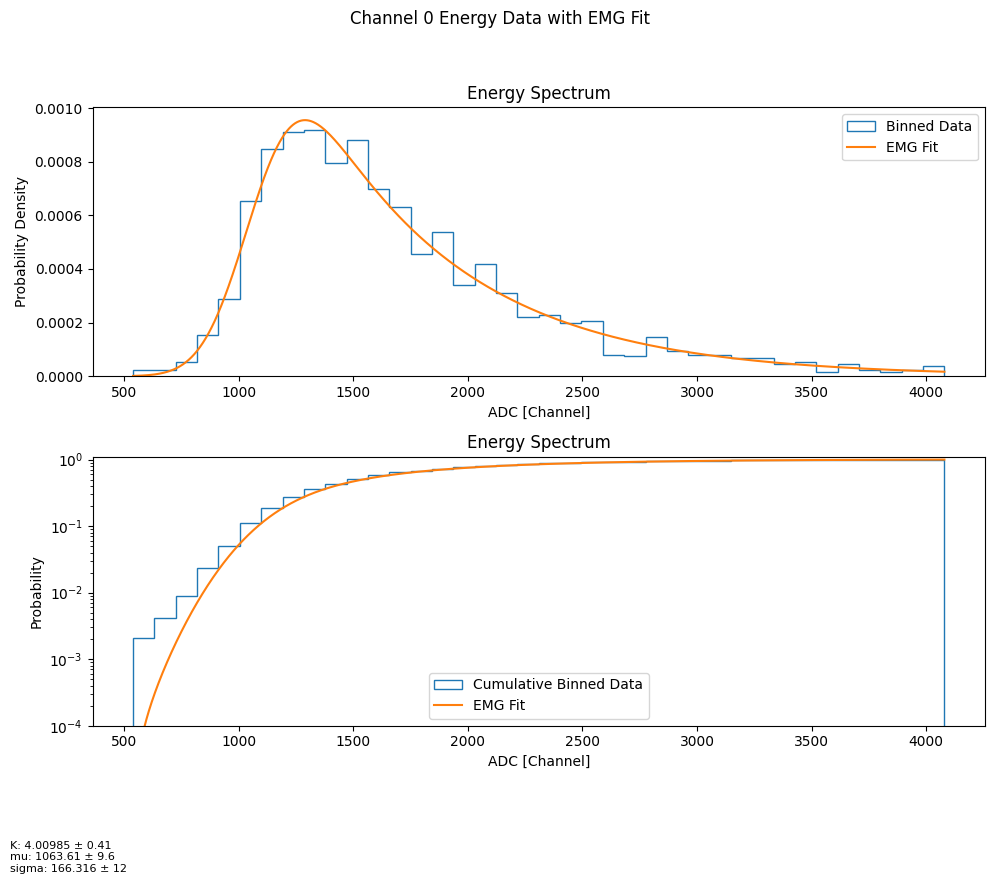


Analysis: Energy data with EMG fit, Channel: 0
       K        |       mu       |     sigma      |
----------------+----------------+----------------+
           2.95 |         817.12 |         161.84 |
 ±         0.40 | ±        11.62 | ±        14.17 |



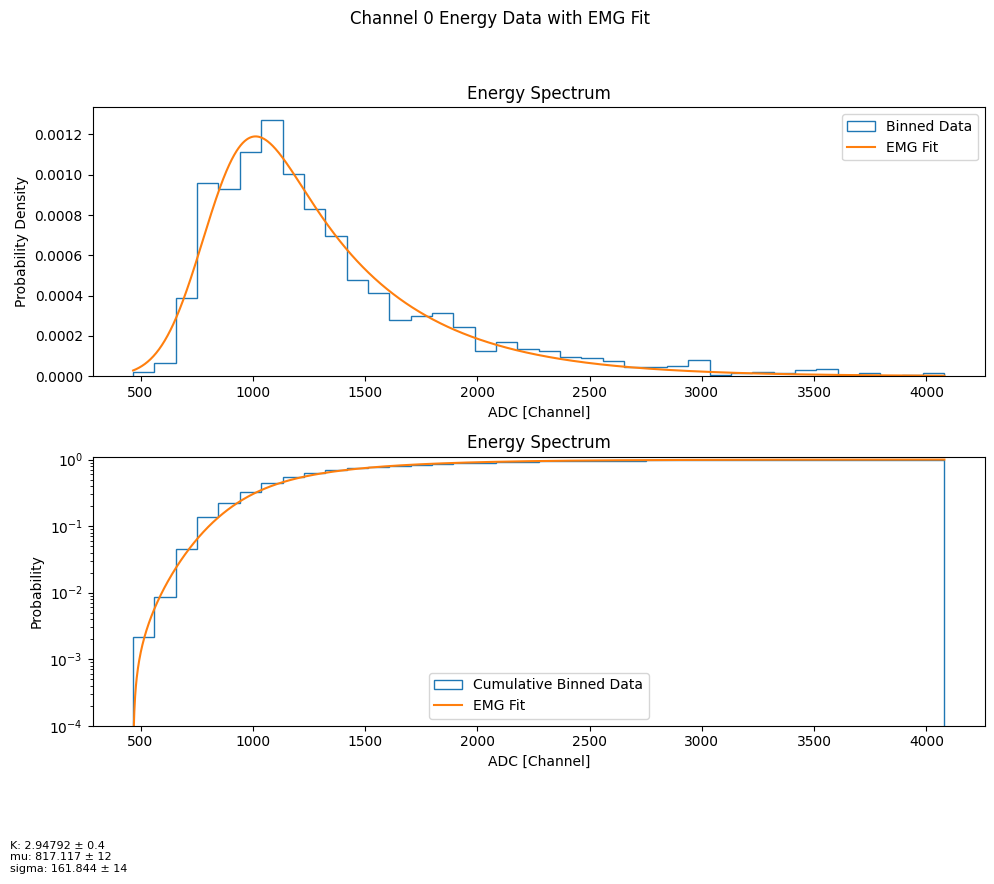

In [11]:
# Perform fitting
cement_Efit, gel_Efit = FitResult(cement121_E,'EMG',0), FitResult(gel121_E,'EMG',0)

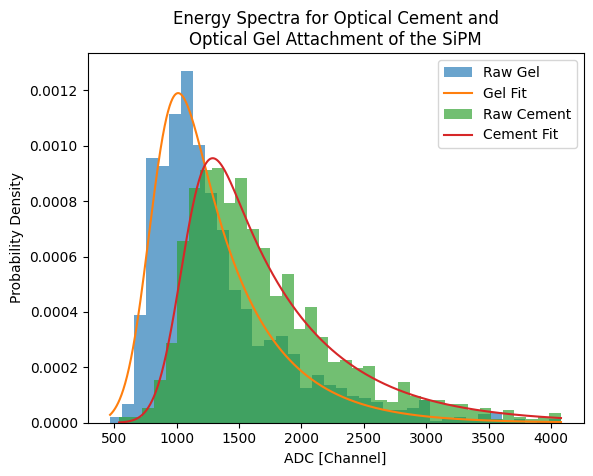

In [16]:
# Plot

plt.title('Energy Spectra for Optical Cement and\nOptical Gel Attachment of the SiPM')
plt.xlabel('ADC [Channel]')
plt.ylabel('Probability Density')

plt.hist(gel121_E,bins=round(np.sqrt(len(gel121_E))),alpha=2/3,label='Raw Gel',density=True)
plt.plot(gel_Efit.xgrid, gel_Efit.ypdf, label='Gel Fit')
plt.hist(cement121_E,bins=round(np.sqrt(len(cement121_E))),alpha=2/3,label='Raw Cement',density=True)
plt.plot(cement_Efit.xgrid, cement_Efit.ypdf, label='Cement Fit')

plt.legend()
plt.show()

In [52]:
1.21977/2.77633*100

43.93461872327857

### Pulse Height


Analysis: Height data with Langauss fit, Channel: 0
     x_mpv      |       xi       |  gauss_sigma   |
----------------+----------------+----------------+
         124.67 |           7.81 |          37.12 |
 ±         2.03 | ±         0.83 | ±         2.66 |

0.10% threshold: 53.9713


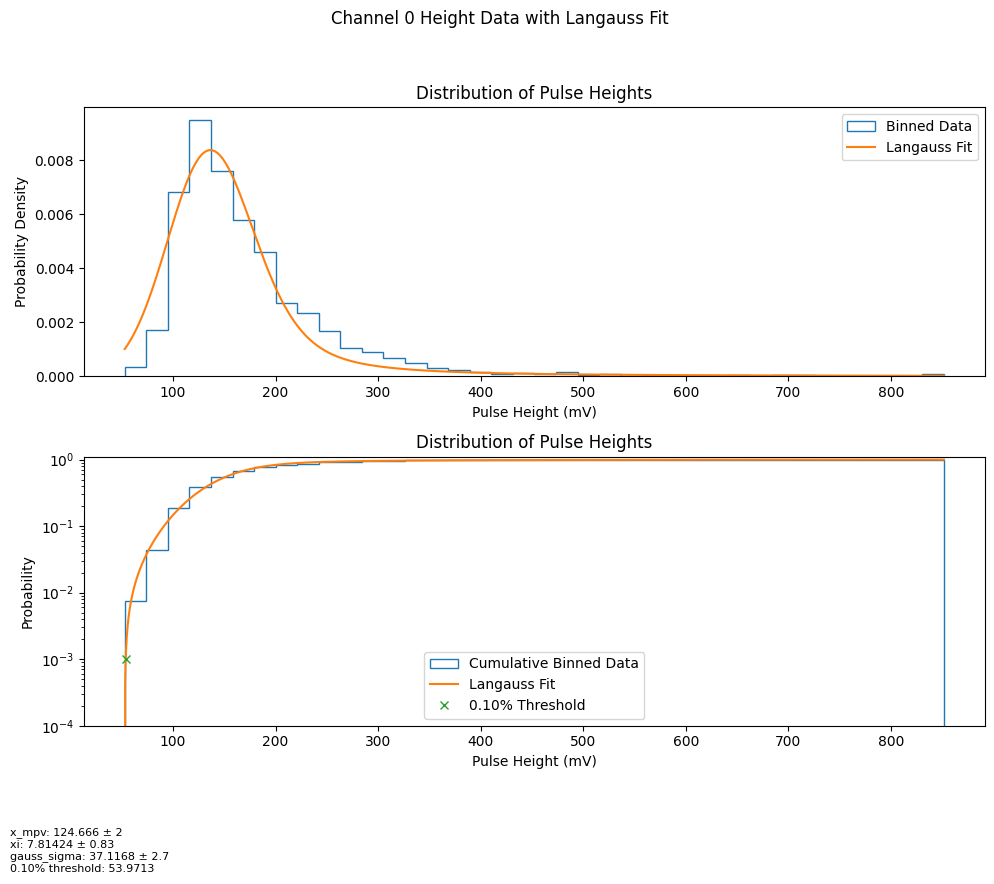


Analysis: Height data with Langauss fit, Channel: 0
     x_mpv      |       xi       |  gauss_sigma   |
----------------+----------------+----------------+
          87.58 |           8.08 |          24.22 |
 ±         1.45 | ±         0.65 | ±         2.35 |

0.10% threshold: 42.5522


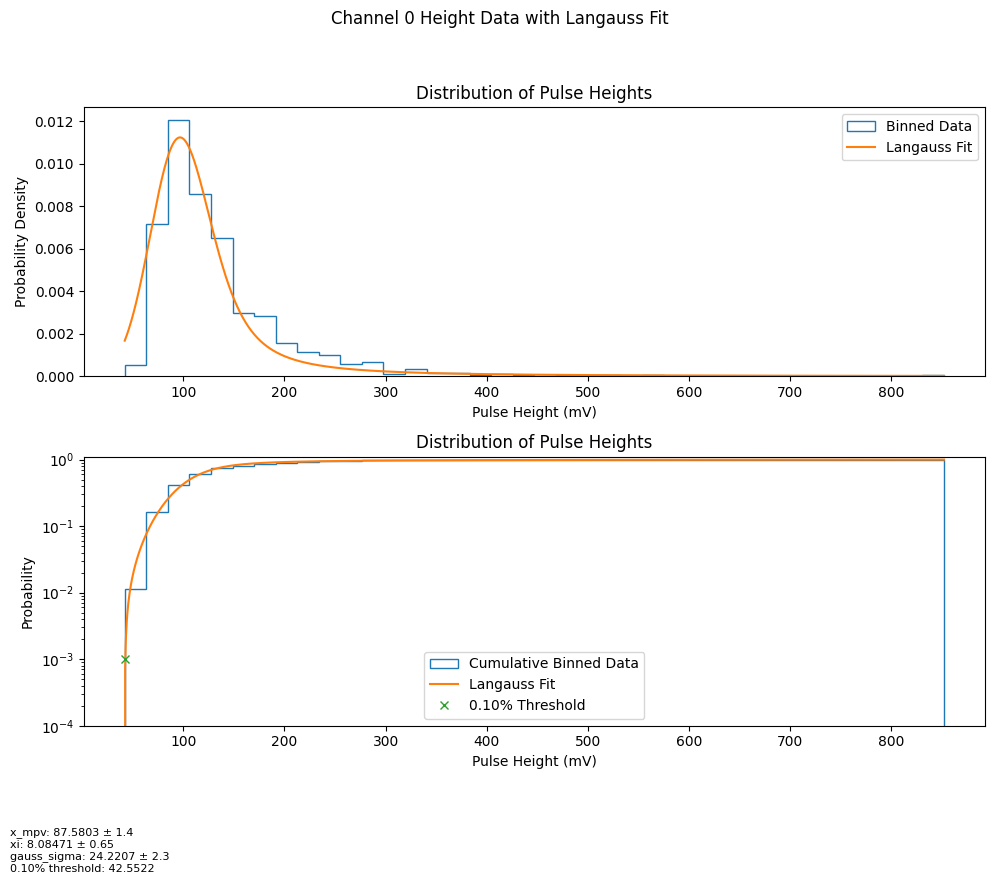

In [20]:
# Perform fitting
cement_phfit, gel_phfit = FitResult(cement121_ph,'Langauss',0), FitResult(gel121_ph,'Langauss',0)

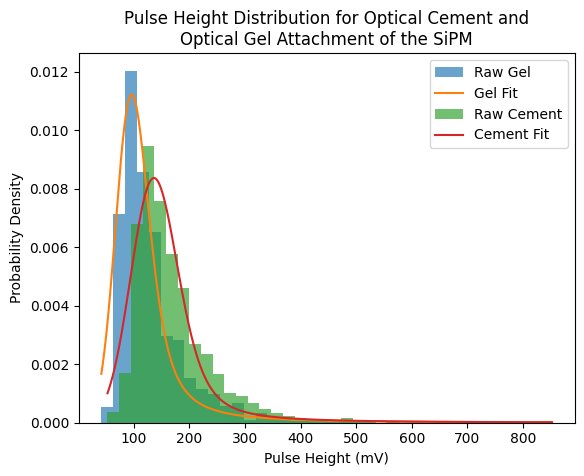

42.552236078305526 53.9712561923929


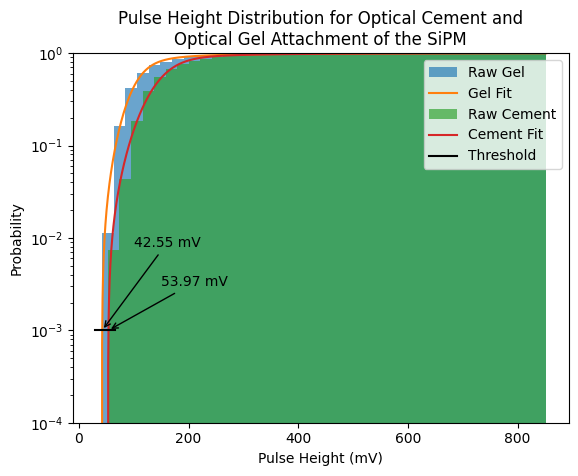

In [54]:
# Plot

## PDF
plt.title('Pulse Height Distribution for Optical Cement and\nOptical Gel Attachment of the SiPM')
plt.xlabel('Pulse Height (mV)')
plt.ylabel('Probability Density')

plt.hist(gel121_ph,bins=round(np.sqrt(len(gel121_ph))),alpha=2/3,label='Raw Gel',density=True)
plt.plot(gel_phfit.xgrid, gel_phfit.ypdf, label='Gel Fit')
plt.hist(cement121_ph,bins=round(np.sqrt(len(cement121_ph))),alpha=2/3,label='Raw Cement',density=True)
plt.plot(cement_phfit.xgrid, cement_phfit.ypdf, label='Cement Fit')

plt.legend()
plt.show()


## CDF
plt.title('Pulse Height Distribution for Optical Cement and\nOptical Gel Attachment of the SiPM')
plt.xlabel('Pulse Height (mV)')
plt.ylabel('Probability')

plt.hist(gel121_ph,bins=round(np.sqrt(len(gel121_ph))),alpha=2/3,label='Raw Gel',density=True, cumulative=True)
plt.plot(gel_phfit.xgrid, gel_phfit.cdf(gel_phfit.xgrid), label='Gel Fit')
plt.hist(cement121_ph,bins=round(np.sqrt(len(cement121_ph))),alpha=2/3,label='Raw Cement',density=True, cumulative=True)
plt.plot(cement_phfit.xgrid, cement_phfit.cdf(cement_phfit.xgrid), label='Cement Fit')
plt.plot(np.linspace(30,66,1000),np.full(1000,1e-3),label='Threshold',color='black',marker='',linestyle='-')
print(gel_phfit.thresh,cement_phfit.thresh,)
plt.annotate(f'{gel_phfit.thresh:.2f} mV',(gel_phfit.thresh,1e-3),xytext=(100,8e-3),arrowprops={'arrowstyle': '->'})
plt.annotate(f'{cement_phfit.thresh:.2f} mV',(cement_phfit.thresh,1e-3),xytext=(150,3e-3),arrowprops={'arrowstyle': '->'})

plt.ylim(1e-4,1)
plt.yscale('log')
plt.legend()
plt.show()

In [53]:
5.23120/5.72925

0.9130689008159881